# Corruption

How much political corruption is present in the society living in that grid cell. No true global gridded corruption dataset exists (🔴 Tier C in `DATASETS.md`) — the concept is inherently country-level and expert-survey based. Candidate sources discussed in `DATASETS.md` are Transparency International's Corruption Perceptions Index (CPI), the World Bank Worldwide Governance Indicators' Control of Corruption (WGI CC), V-Dem's Political Corruption Index (`v2x_corr`), and ICRG.

We use **V-Dem `v2x_corr`** as the single source here because:

* CPI and WGI CC are both aggregations-of-aggregations — they blend ~13 and ~30 upstream sources respectively, and V-Dem is one of those sources for both. Using V-Dem directly is the more methodologically transparent choice.
* The V-Dem `.RData` bundle is **already cached** by `34_human_freedom.ipynb`, so this notebook adds zero new downloads and reuses the same Natural Earth polygons.
* V-Dem publishes yearly through 2025 with sub-indices for executive / legislative / judicial / public-sector corruption — room to break the score down later without swapping datasets.

V-Dem's `v2x_corr` runs `[0, 1]` where **higher = more corrupt**, so we sign-invert to the atlas convention (higher = less corrupt = better). Rasterization mirrors `19_climate_vulnerability.ipynb` and `34_human_freedom.ipynb`: join by ISO3 to Natural Earth 50m admin_0 polygons, rasterize via `regionmask` onto the 0.5° grid, mask ocean via `is_land` from `grid.nc`. Values are flat inside each country border by construction (🔴 Tier C).

In [1]:
import httpx
import numpy as np
import pandas as pd
import pyreadr
import xarray as xr

from common import RAW_DIR, load_country_mask, load_grid, plot_map, save_variable

VARIABLE = 'corruption'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Fetch raw data

### 1a. V-Dem Country-Year dataset

Reuses the `.RData` cached by `34_human_freedom.ipynb`. If that notebook hasn't been run yet, fall back to a fresh download from the [`vdemdata` GitHub repo](https://github.com/vdeminstitute/vdemdata) — same asset, same ~34 MB payload, refreshed with each yearly V-Dem release (currently v15, through 2025). `pyreadr` reads it directly, so we skip the auth-walled Country-Year CSV on `v-dem.net`.

In [2]:
VDEM_URL = 'https://raw.githubusercontent.com/vdeminstitute/vdemdata/master/data/vdem.RData'
vdem_cached = RAW_DIR / 'human_freedom' / 'vdem.RData'
vdem_local = variable_raw / 'vdem.RData'

if vdem_cached.exists():
    vdem_path = vdem_cached
elif vdem_local.exists():
    vdem_path = vdem_local
else:
    print(f'downloading {VDEM_URL}')
    r = httpx.get(VDEM_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=180, follow_redirects=True)
    r.raise_for_status()
    vdem_local.write_bytes(r.content)
    vdem_path = vdem_local

print(f'using {vdem_path} ({vdem_path.stat().st_size / 1024**2:.1f} MB)')

using /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/raw/human_freedom/vdem.RData (32.3 MB)


## 2. Extract latest Political Corruption Index per country

The V-Dem dataset has one row per country-year back to 1789 and ~4 600 indicator columns. Keep only what we need: for each `country_text_id`, take the most recent year with a non-null `v2x_corr`. That is our country baseline. Higher `v2x_corr` = more corrupt (V-Dem convention).

In [3]:
vdem = pyreadr.read_r(vdem_path)['vdem'][['country_name', 'country_text_id', 'year', 'v2x_corr']]
vdem = vdem.dropna(subset=['v2x_corr'])

latest_idx = vdem.groupby('country_text_id')['year'].idxmax()
scores = (
    vdem.loc[latest_idx, ['country_text_id', 'country_name', 'year', 'v2x_corr']]
    .rename(columns={'country_text_id': 'ISO3', 'v2x_corr': 'corruption'})
    .set_index('ISO3')
)

print(f'{len(scores)} countries with a Political Corruption Index score '
      f'(latest year seen: {int(scores["year"].max())}, range '
      f'[{scores["corruption"].min():.3f}, {scores["corruption"].max():.3f}])')
scores.head()

200 countries with a Political Corruption Index score (latest year seen: 2025, range [0.004, 0.968])


,country_name,year,corruption
ISO3,,,
AFG,Afghanistan,2025.0,0.769
AGO,Angola,2025.0,0.570
ALB,Albania,2025.0,0.624
ARE,United Arab Emirates,2025.0,0.105
ARG,Argentina,2025.0,0.415


## 3. Rasterize onto the 0.5° grid

Load the cached admin_0 country mask from `03_region_mask.ipynb` and join V-Dem `v2x_corr` onto it by ISO3. Sign-invert (negate) so higher = less corrupt = better for livability, matching the atlas convention used by `weighted_score` in `90_scoring.ipynb`. Mask ocean via `is_land`.

In [4]:
grid = load_grid()
iso_per_cell = load_country_mask()

lookup_flat = (
    pd.Series(iso_per_cell.values.ravel())
    .map(scores['corruption'])
    .to_numpy(dtype='float32')
)
raster = lookup_flat.reshape(iso_per_cell.shape)

values = (
    xr.DataArray(-raster, coords=iso_per_cell.coords, dims=iso_per_cell.dims, name=VARIABLE)
    .where(grid.is_land == 1)
)
values.attrs['units'] = 'negated V-Dem Political Corruption Index (higher = less corrupt = better)'
values.attrs['source'] = (
    f'V-Dem v2x_corr (latest per country, up to year {int(scores["year"].max())})'
)
values.attrs['orientation'] = 'higher = less corrupt (already inverted for atlas)'

land_cells = int((grid.is_land == 1).sum())
covered = int(values.notnull().sum())
print(f'{covered}/{land_cells} land cells covered ({100 * covered / land_cells:.1f}%)')
print(f'values range: {float(values.min()):.3f} .. {float(values.max()):.3f}')

64271/68294 land cells covered (94.1%)
values range: -0.968 .. -0.004


## 4. Plot

<Axes: title={'center': 'Corruption (V-Dem, inverted — higher = less corrupt)'}, xlabel='longitude', ylabel='latitude'>

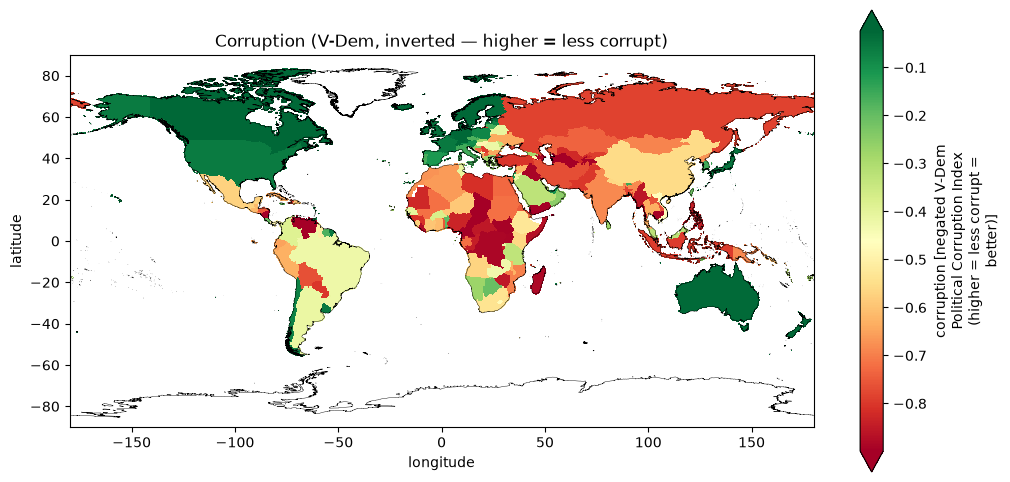

In [5]:
plot_map(values, cmap='RdYlGn', robust=True, title='Corruption (V-Dem, inverted — higher = less corrupt)')

## 5. Save

In [6]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/corruption.nc
